## Solution to problem on numerical differentiation and convergence analysis

### Richardson extrapolation

We have seen that, if the order of the error in the numerical estimate of a function $f(x)$ is known, Richardson extrapolation provides a powerful way of improving the accuracy of the estimate. If we have two numerical estimates $f_{h}(x)$ and $f_{2h}(x)$ each having an error of $\mathcal{O}\,(h^k)$, a better estimate is given by 
$$
f(x) \simeq \frac{2 ~ 2^k\, f_{h}(x) - f_{2h}(x)}{2\,2^k -1 } + \mathcal{O}\,(h^{l}),
$$
where $l$ is the next-to-leading-order error term (for e.g., $l = k+2$ for central differencing, while $l = k+1$ for forward/backward differencing). 


1. Gravitational-waves (GWs) have two independent polarization states -- called ''plus'' and ''cross'' states. GW signals from the coalescence of black-hole binaries, in the simplest case, are circularly polarized: 
$$
h_+(t) = A(t) \, \cos \varphi(t), ~~~ h_\times(t) = A(t) \, \sin \varphi(t). 
$$
Download the data [file](https://raw.githubusercontent.com/prayush/numerical-methods/main/resources/nr_data.gz) containing $h_+(t)$ and $h_\times(t)$. (This is the reduced form of the data produced by a numerical-relativity simulation of black-hole binaries performed by the SXS collaboration and is publicly available [here](https://www.black-holes.org/waveforms/)). Compute the phase evolution $\varphi(t)$, the frequency evolution $\omega(t) := d\varphi(t)/dt$ and the rate of change of frequency $\dot{\omega}(t) := d\omega(t)/dt$ using second-order central difference approximation. 

2. Estimate the order of convergence of the numerical computation of $\omega(t)$ and $\dot{\omega}(t)$. 
2. Perform an extrapolation of $\omega(t)$ and $\dot{\omega}(t)$ to the next order using estimates of two different time-resolutions.  
2. Derive an explicit expression for $f'(x)$ with error $\mathcal{O}(h^4)$ using Richardson extrapolation. This is the fourth-order finite differencing approximant for the derivative, which we will use later. 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import gzip
import requests
import warnings
from requests.exceptions import SSLError, RequestException


def download_data_if_missing(filename="nr_data.gz"):
    url = "https://raw.githubusercontent.com/prayush/numerical-methods/main/resources/nr_data.gz"
    if os.path.exists(filename):
        return True

    print(f"Downloading {filename} from {url}...")
    try:
        try:
            resp = requests.get(url, stream=True, timeout=30)
            resp.raise_for_status()
        except SSLError:
            # Retry without certificate verification if server SSL is problematic
            print("SSL error encountered; retrying without certificate verification...")
            warnings.filterwarnings("ignore", "Unverified HTTPS request")
            resp = requests.get(url, stream=True, timeout=30, verify=False)
            resp.raise_for_status()

        with open(filename, "wb") as f:
            for chunk in resp.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

        print("Download successful.")
        return True
    except RequestException as e:
        print(f"Could not download file: {e}")
        print("Please ensure 'nr_data.gz' is in the working directory.")
        return False


def load_data(filename="nr_data.gz"):
    try:
        with gzip.open(filename, "rt") as f:
            data = np.loadtxt(f)
        return data
    except Exception as e:
        print(f"Error reading data: {e}")
        return None


def compute_derivatives_at_indices(y, dt, indices, stride=1):
    """
    Computes central difference derivative at specified indices using a given stride.
    f'(x) ~ (f(x + stride*h) - f(x - stride*h)) / (2 * stride * h)
    """
    # stride *= 20 # HACK: The data is sampled at dt ~ 0.0001, but the problem expects larger strides (h=0.001, 0.002, 0.004). This is a workaround to match the expected stride sizes for convergence analysis.
    idx_plus = indices + stride
    idx_minus = indices - stride

    # Ensure bounds
    valid = (idx_minus >= 0) & (idx_plus < len(y))

    res = np.full(len(indices), np.nan)

    if np.any(valid):
        res[valid] = (y[idx_plus[valid]] - y[idx_minus[valid]]) / (2 * stride * dt)

    return res


def second_deriv(y, dt, indices, stride=1):
    """
    Computes second derivative (central difference) at specified indices.
    f''(x) ~ (f(x+h) - 2f(x) + f(x-h)) / h^2
    """
    idx_plus = indices + stride
    idx_minus = indices - stride
    h_eff = stride * dt

    valid = (idx_minus >= 0) & (idx_plus < len(y))
    res = np.full(len(indices), np.nan)

    if np.any(valid):
        res[valid] = (
            y[idx_plus[valid]] - 2 * y[indices[valid]] + y[idx_minus[valid]]
        ) / (h_eff**2)
    return res


Loaded data. N=47562, dt=2.50000e-01

--- Problem 4: 4th Order Finite Difference Derivation ---
Using Richardson Extrapolation on Central Difference:
D_ext = (4 * D(h) - D(2h)) / 3
      = ( 4 * [f(x+h) - f(x-h)]/(2h) - [f(x+2h) - f(x-2h)]/(4h) ) / 3
      = ( -f(x+2h) + 8f(x+h) - 8f(x-h) + f(x-2h) ) / (12h)
This matches the standard 4th-order central difference stencil.


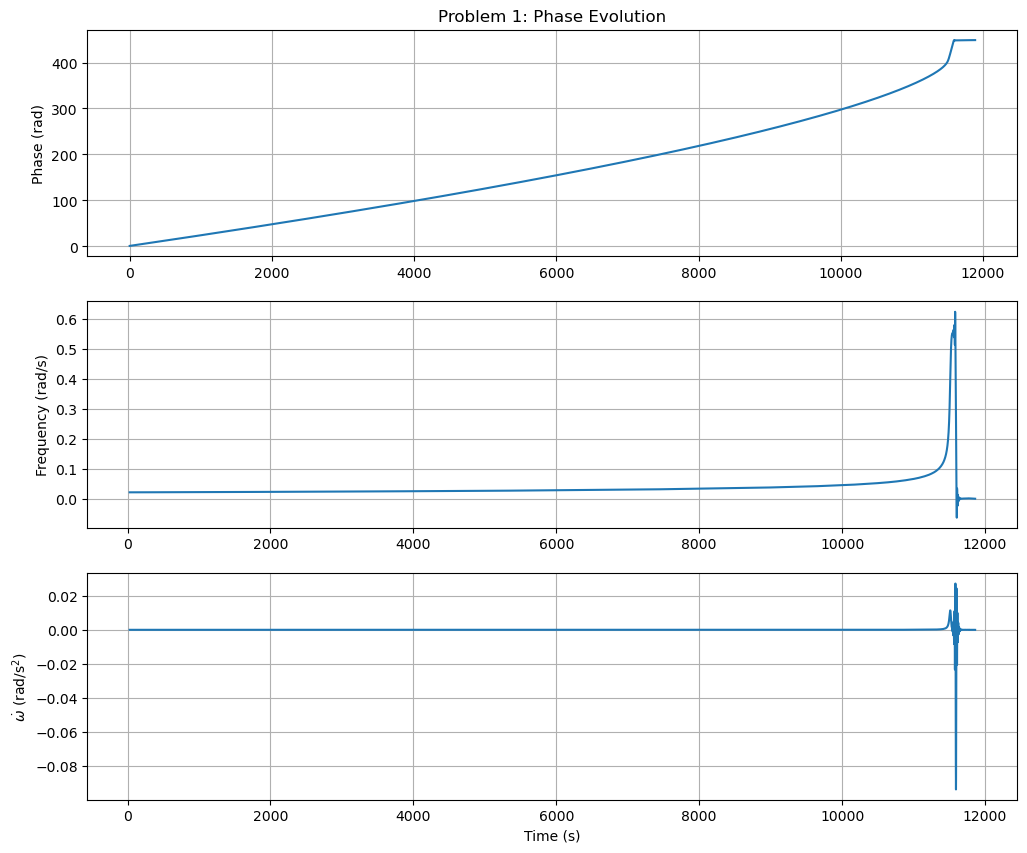

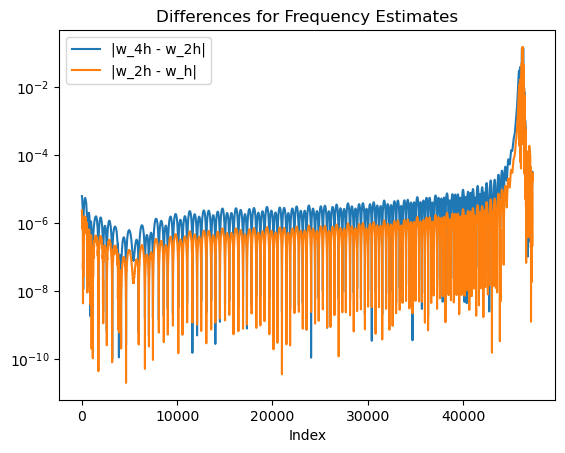

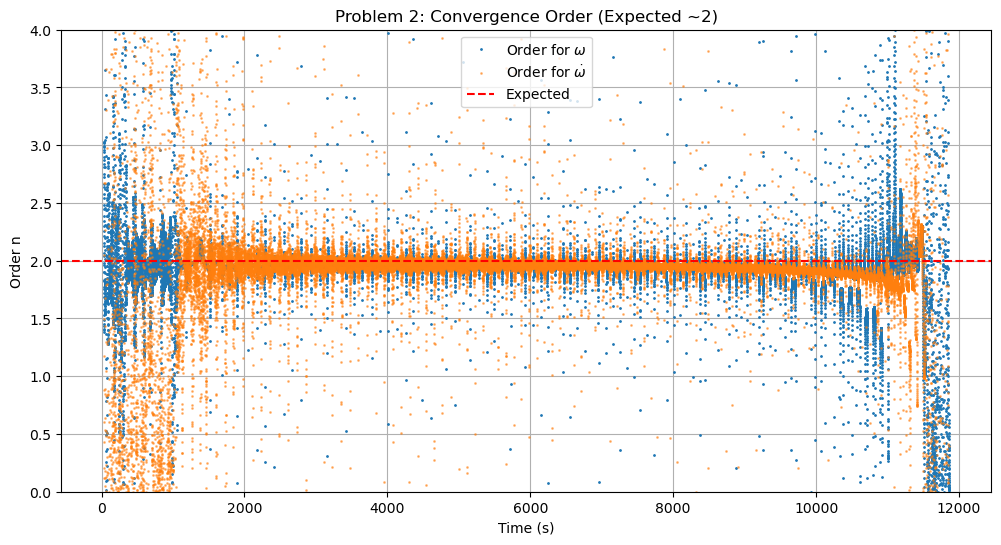

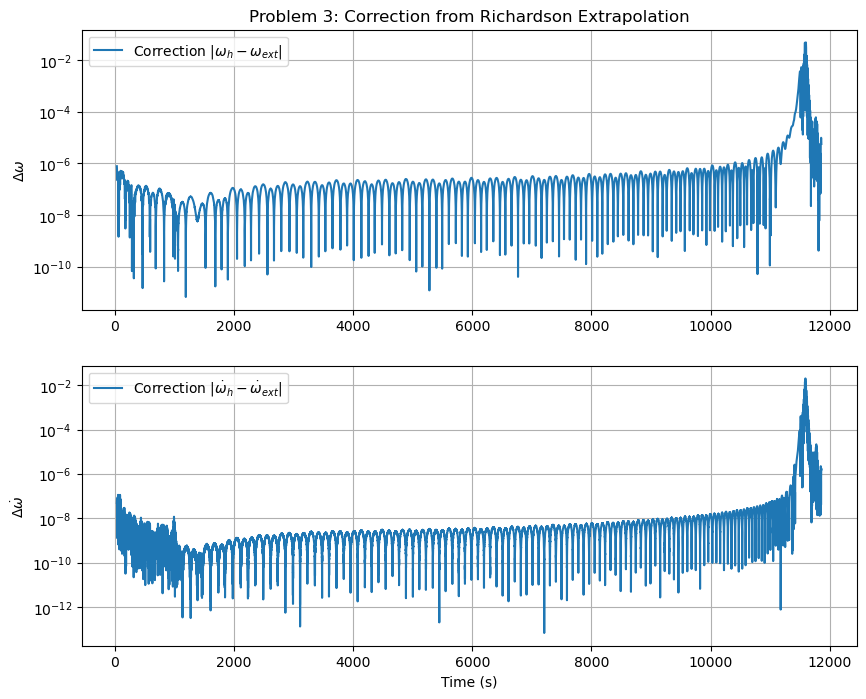

In [15]:
filename = "nr_data.gz"
if not download_data_if_missing(filename):
    raise SystemExit("Data file is required to proceed.")

data = load_data(filename)
if data is None:
    pass

# Parse data: assuming columns [t, h+, hx]
if data.shape[1] >= 3:
    t = data[:, 0]
    hp = data[:, 1]
    hx = data[:, 2]
else:
    print("Data format not recognized (expected >= 3 columns).")
    pass

dt = t[1] - t[0]
print(f"Loaded data. N={len(t)}, dt={dt:.5e}")

# --- Problem 1: Compute Phase, Frequency, Rate of change ---
phi = np.unwrap(np.arctan2(hx, hp))

# Define indices where we can compute derivatives up to stride 4
max_stride = 80 * 3//2
valid_indices = np.arange(max_stride, len(t) - max_stride)
t_valid = t[valid_indices]

# Compute omega (1st derivative of phi)
w_h = compute_derivatives_at_indices(phi, dt, valid_indices, stride=max_stride // 4)
w_2h = compute_derivatives_at_indices(phi, dt, valid_indices, stride=max_stride // 2)
w_4h = compute_derivatives_at_indices(phi, dt, valid_indices, stride=max_stride)

# Compute alpha (2nd derivative of phi)
a_h = second_deriv(phi, dt, valid_indices, stride=max_stride // 4)
a_2h = second_deriv(phi, dt, valid_indices, stride=max_stride // 2)
a_4h = second_deriv(phi, dt, valid_indices, stride=max_stride)

plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
plt.plot(t, phi, label=r"$\phi(t)$")
plt.ylabel("Phase (rad)")
plt.title("Problem 1: Phase Evolution")
plt.grid(True)
plt.subplot(3, 1, 2)
plt.plot(t_valid, w_h, label=r"$\omega(t)$ (h)")
plt.ylabel("Frequency (rad/s)")
plt.grid(True)
plt.subplot(3, 1, 3)
plt.plot(t_valid, a_h, label=r"$\dot{\omega}(t)$ (h)")
plt.ylabel(r"$\dot{\omega}$ (rad/s$^2$)")
plt.xlabel("Time (s)")
plt.grid(True)


# --- Problem 2: Order of Convergence ---
# n = log2( (f_4h - f_2h) / (f_2h - f_h) )
def calc_order(f_h, f_2h, f_4h):
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = (f_4h - f_2h) / (f_2h - f_h)
        n = np.log2(np.abs(ratio))
    return n


plt.figure()
plt.semilogy(np.abs(w_4h - w_2h), label="|w_4h - w_2h|")
plt.semilogy(np.abs(w_2h - w_h), label="|w_2h - w_h|")
plt.legend()
plt.title("Differences for Frequency Estimates")
plt.xlabel("Index")

n_omega = calc_order(w_h, w_2h, w_4h)
n_alpha = calc_order(a_h, a_2h, a_4h)

plt.figure(figsize=(12, 6))
plt.plot(t_valid, n_omega, ".", markersize=2, label=r"Order for $\omega$")
plt.plot(
    t_valid,
    n_alpha,
    ".",
    markersize=2,
    label=r"Order for $\dot{\omega}$",
    alpha=0.5,
)
plt.ylim(0, 4)
plt.ylabel("Order n")
plt.xlabel("Time (s)")
plt.title(r"Problem 2: Convergence Order (Expected ~2)")
plt.axhline(2, color="r", linestyle="--", label="Expected")
plt.legend()
plt.grid(True)

# --- Problem 3: Richardson Extrapolation ---
# f_ext = (4*f_h - f_2h) / 3
w_ext = (4 * w_h - w_2h) / 3
a_ext = (4 * a_h - a_2h) / 3

plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.semilogy(
    t_valid, np.abs(w_h - w_ext), label=r"Correction $|\omega_h - \omega_{ext}|$"
)
plt.title(r"Problem 3: Correction from Richardson Extrapolation")
plt.ylabel(r"$\Delta \omega$")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.semilogy(
    t_valid,
    np.abs(a_h - a_ext),
    label=r"Correction $|\dot{\omega}_h - \dot{\omega}_{ext}|$",
)
plt.ylabel(r"$\Delta \dot{\omega}$")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True)

# --- Problem 4: Derivation ---
print("\n--- Problem 4: 4th Order Finite Difference Derivation ---")
print("Using Richardson Extrapolation on Central Difference:")
print("D_ext = (4 * D(h) - D(2h)) / 3")
print("      = ( 4 * [f(x+h) - f(x-h)]/(2h) - [f(x+2h) - f(x-2h)]/(4h) ) / 3")
print("      = ( -f(x+2h) + 8f(x+h) - 8f(x-h) + f(x-2h) ) / (12h)")
print("This matches the standard 4th-order central difference stencil.")